# Running Efficiency Scorer — XGBoost Model
This notebook trains an XGBoost model that scores a runner's efficiency (0–100).
It uses the same dataset as the marathon predictor but derives a composite efficiency target.

**Output:** `efficiency_model.pkl` — loaded by `predict_service.py` at `/efficiency-score`

Run each cell top to bottom.

## Step 1 — Install packages

In [ ]:
pip install xgboost scikit-learn pandas numpy matplotlib seaborn

## Step 2 — Import libraries

In [2]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

print('All libraries imported successfully')

All libraries imported successfully


## Step 3 — Load data

In [3]:
train_df = pd.read_csv('train.csv')
test_df  = pd.read_csv('test.csv')

print(f'Train shape: {train_df.shape}')
print(f'Test shape:  {test_df.shape}')
train_df.head()

Train shape: (80000, 41)
Test shape:  (20000, 40)


,runner_id,age,gender,running_experience_months,previous_marathon_count,training_program,motivation_level,personal_best_minutes,weekly_mileage_km,weekly_mileage_miles,...,run_club_attendance_rate,warmup_adherence_pct,stretching_adherence_pct,marathon_date,marathon_weather,course_difficulty,target_finish_time_minutes,actual_finish_time_minutes,mental_preparation_score,medal_outcome
0,R009432,25,Male,48,0,Intermediate,4,NaN,20.0,12.4,...,0,70,29,2025-02-02,Hot,Mixed,254,297.0,5,0
1,R077741,43,Female,151,2,Advanced,1,196.0,20.0,12.4,...,0,94,0,2024-02-11,Sunny,Mixed,201,231.0,7,1
2,R034376,32,Female,82,3,Advanced,6,211.0,23.1,14.4,...,54,47,39,2025-03-27,Rainy,Flat,204,234.0,9,1
3,R020754,57,Male,6,0,Beginner,8,NaN,27.3,17.0,...,63,77,45,2024-04-16,Sunny,Hilly,258,276.0,3,3
4,R001301,54,Female,11,0,Beginner,3,NaN,20.0,12.4,...,20,64,40,2025-10-21,Cloudy,Mixed,245,296.0,8,0


## Step 4 — Explore key columns

In [4]:
efficiency_cols = [
    'weekly_mileage_km', 'runs_per_week', 'training_adherence_pct',
    'resting_heart_rate_bpm', 'vo2_max', 'recovery_score',
    'consecutive_weeks_no_miss', 'actual_finish_time_minutes', 'target_finish_time_minutes'
]
print('Missing values in key columns:')
print(train_df[efficiency_cols].isnull().sum())
print()
train_df[efficiency_cols].describe()

Missing values in key columns:
weekly_mileage_km                0
runs_per_week                    0
training_adherence_pct           0
resting_heart_rate_bpm           0
vo2_max                       9611
recovery_score                   0
consecutive_weeks_no_miss        0
actual_finish_time_minutes    1989
target_finish_time_minutes       0
dtype: int64



,weekly_mileage_km,runs_per_week,training_adherence_pct,resting_heart_rate_bpm,vo2_max,recovery_score,consecutive_weeks_no_miss,actual_finish_time_minutes,target_finish_time_minutes
count,80000.000000,80000.000000,80000.000000,80000.000000,70389.000000,80000.000000,80000.000000,78011.000000,80000.000000
mean,29.940183,4.356975,80.386075,75.223213,53.757363,6.674585,12.326562,287.931407,249.308687
std,17.392518,0.896649,11.804666,6.483532,8.507076,2.067715,2.499604,33.648005,30.372115
min,20.000000,3.000000,40.000000,45.000000,35.000000,1.000000,2.000000,171.000000,150.000000
25%,20.000000,4.000000,73.000000,72.000000,47.847340,5.300000,11.000000,265.000000,228.000000
50%,20.600000,4.000000,81.000000,78.000000,53.557431,6.800000,12.000000,290.000000,252.000000
75%,34.300000,5.000000,89.000000,80.000000,59.451220,8.200000,14.000000,313.000000,272.000000
max,119.994348,7.000000,100.000000,80.000000,75.000000,10.000000,16.000000,400.000000,350.000000


## Step 5 — Build efficiency score (target variable)

We don't have a direct 'efficiency' label, so we derive it from what efficiency actually means:

| Component | Weight | Logic |
|---|---|---|
| Race execution | 30 pts | How close actual time was to target |
| HR efficiency | 25 pts | Low resting HR + high VO2 max |
| Training adherence | 20 pts | Consistency of workouts |
| Recovery | 15 pts | How well body handles training load |
| Streak | 10 pts | Consecutive weeks without missing |


In [5]:
def compute_efficiency_score(row):
    score = 0.0

    # 1. Race execution (30 pts)
    if pd.notna(row.get('actual_finish_time_minutes')) and pd.notna(row.get('target_finish_time_minutes')):
        actual = row['actual_finish_time_minutes']
        target = row['target_finish_time_minutes']
        if target > 0:
            ratio = actual / target  # 1.0 = perfect, >1 = slower than target
            exec_score = max(0, 30 - max(0, (ratio - 1.0)) * 600)
            score += exec_score
    else:
        score += 15  # neutral if no race data

    # 2. HR efficiency (25 pts)
    if pd.notna(row.get('resting_heart_rate_bpm')) and pd.notna(row.get('vo2_max')):
        hr  = row['resting_heart_rate_bpm']
        vo2 = row['vo2_max']
        hr_pts    = max(0, 25 - (hr - 40) * 0.625)
        vo2_bonus = min(5, (vo2 - 40) * 0.2) if vo2 > 40 else 0
        score += min(25, hr_pts + vo2_bonus)
    else:
        score += 12

    # 3. Training adherence (20 pts)
    if pd.notna(row.get('training_adherence_pct')):
        score += (row['training_adherence_pct'] / 100) * 20
    else:
        score += 10

    # 4. Recovery score (15 pts)
    if pd.notna(row.get('recovery_score')):
        score += min(15, (row['recovery_score'] / 10) * 15)
    else:
        score += 7

    # 5. Streak bonus (10 pts)
    if pd.notna(row.get('consecutive_weeks_no_miss')):
        score += min(10, row['consecutive_weeks_no_miss'] * 0.5)
    else:
        score += 5

    return round(min(100, max(0, score)), 2)

train_df['efficiency_score'] = train_df.apply(compute_efficiency_score, axis=1)
test_df['efficiency_score']  = test_df.apply(compute_efficiency_score, axis=1)

print('Efficiency score distribution:')
print(train_df['efficiency_score'].describe())

Efficiency score distribution:
count    80000.000000
mean        39.061701
std          7.075357
min         17.210000
25%         34.020000
50%         38.630000
75%         43.900000
max         73.470000
Name: efficiency_score, dtype: float64


## Step 6 — Visualise efficiency score distribution

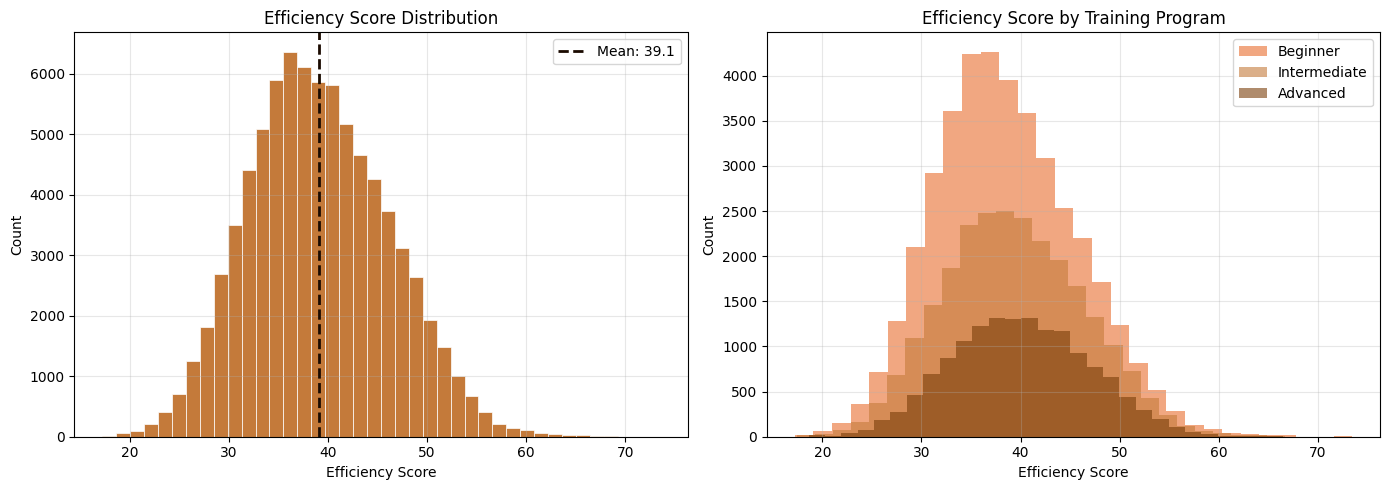

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution
axes[0].hist(train_df['efficiency_score'], bins=40, color='#c47a3a', edgecolor='white', linewidth=0.5)
axes[0].axvline(train_df['efficiency_score'].mean(), color='#1a0a00', linestyle='--', lw=2,
                label=f"Mean: {train_df['efficiency_score'].mean():.1f}")
axes[0].set_xlabel('Efficiency Score')
axes[0].set_ylabel('Count')
axes[0].set_title('Efficiency Score Distribution')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# By training program
for prog, color in zip(['Beginner', 'Intermediate', 'Advanced'], ['#e86d2e', '#c47a3a', '#7a3e0a']):
    subset = train_df[train_df['training_program'] == prog]['efficiency_score']
    axes[1].hist(subset, bins=30, alpha=0.6, label=prog, color=color)
axes[1].set_xlabel('Efficiency Score')
axes[1].set_ylabel('Count')
axes[1].set_title('Efficiency Score by Training Program')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Step 7 — Correlation analysis

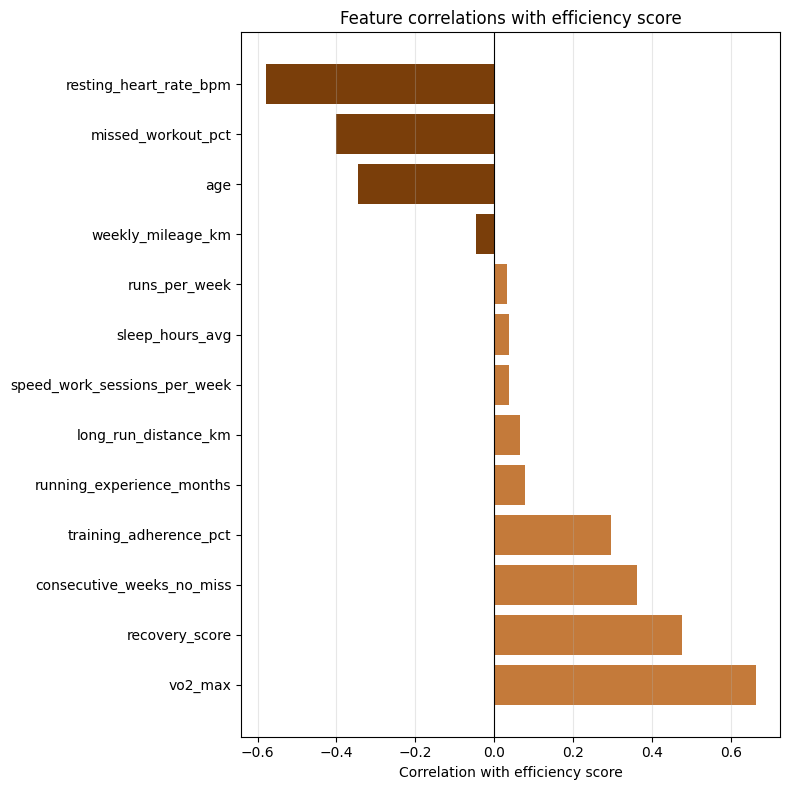

                              efficiency_score
vo2_max                               0.663092
recovery_score                        0.475883
consecutive_weeks_no_miss             0.363304
training_adherence_pct                0.297087
running_experience_months             0.078113
long_run_distance_km                  0.064969
speed_work_sessions_per_week          0.037117
sleep_hours_avg                       0.036997
runs_per_week                         0.032944
weekly_mileage_km                    -0.046233
age                                  -0.346402
missed_workout_pct                   -0.400477
resting_heart_rate_bpm               -0.579814


In [7]:
numeric_cols = [
    'weekly_mileage_km', 'runs_per_week', 'long_run_distance_km',
    'speed_work_sessions_per_week', 'training_adherence_pct',
    'running_experience_months', 'resting_heart_rate_bpm', 'vo2_max',
    'recovery_score', 'consecutive_weeks_no_miss', 'missed_workout_pct',
    'sleep_hours_avg', 'age', 'efficiency_score'
]

corr = train_df[numeric_cols].corr()[['efficiency_score']].drop('efficiency_score')
corr = corr.sort_values('efficiency_score', ascending=False)

plt.figure(figsize=(8, 8))
colors = ['#c47a3a' if v > 0 else '#7a3e0a' for v in corr['efficiency_score']]
plt.barh(corr.index, corr['efficiency_score'], color=colors)
plt.axvline(0, color='black', lw=0.8)
plt.xlabel('Correlation with efficiency score')
plt.title('Feature correlations with efficiency score')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print(corr)

## Step 8 — Select features & handle missing values

In [8]:
FEATURES = [
    'weekly_mileage_km',
    'runs_per_week',
    'long_run_distance_km',
    'speed_work_sessions_per_week',
    'training_adherence_pct',
    'running_experience_months',
    'resting_heart_rate_bpm',
    'vo2_max',
    'recovery_score',
    'consecutive_weeks_no_miss',
    'missed_workout_pct',
    'sleep_hours_avg',
    'age',
    'gender',
    'training_program',
]

# Fill numeric missing values with median
fill_medians = {}
numeric_features = [f for f in FEATURES if f not in ['gender', 'training_program']]

for col in numeric_features:
    median_val = train_df[col].median()
    fill_medians[col] = median_val
    train_df[col] = train_df[col].fillna(median_val)
    test_df[col]  = test_df[col].fillna(median_val)

print('Missing values after fill:')
print(train_df[FEATURES].isnull().sum())

Missing values after fill:
weekly_mileage_km               0
runs_per_week                   0
long_run_distance_km            0
speed_work_sessions_per_week    0
training_adherence_pct          0
running_experience_months       0
resting_heart_rate_bpm          0
vo2_max                         0
recovery_score                  0
consecutive_weeks_no_miss       0
missed_workout_pct              0
sleep_hours_avg                 0
age                             0
gender                          0
training_program                0
dtype: int64


## Step 9 — Encode categorical features

In [9]:
label_encoders = {}
categorical_cols = ['gender', 'training_program']

for col in categorical_cols:
    le = LabelEncoder()
    combined = pd.concat([train_df[col], test_df[col]], axis=0).astype(str)
    le.fit(combined)
    train_df[col] = le.transform(train_df[col].astype(str))
    test_df[col]  = le.transform(test_df[col].astype(str))
    label_encoders[col] = le
    print(f'Encoded {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}')

Encoded gender: {'Female': np.int64(0), 'Male': np.int64(1), 'Non-binary': np.int64(2)}
Encoded training_program: {'Advanced': np.int64(0), 'Beginner': np.int64(1), 'Intermediate': np.int64(2)}


## Step 10 — Train XGBoost model

In [10]:
X_train = train_df[FEATURES]
y_train = train_df['efficiency_score']
X_test  = test_df[FEATURES]
y_test  = test_df['efficiency_score']

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.1, random_state=42
)

print(f'Training on {len(X_tr)} samples, validating on {len(X_val)}')

model = XGBRegressor(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=40,
    eval_metric='mae',
)

model.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    verbose=50,
)

print('\nTraining complete!')

Training on 72000 samples, validating on 8000
[0]	validation_0-mae:5.57236
[50]	validation_0-mae:1.60679
[100]	validation_0-mae:1.00521
[150]	validation_0-mae:0.88635
[200]	validation_0-mae:0.85301
[250]	validation_0-mae:0.83851
[300]	validation_0-mae:0.83421
[350]	validation_0-mae:0.83196
[399]	validation_0-mae:0.83079

Training complete!


## Step 11 — Evaluate model

In [11]:
val_pred  = model.predict(X_val)
test_pred = model.predict(X_test)

val_mae   = mean_absolute_error(y_val, val_pred)
test_mae  = mean_absolute_error(y_test, test_pred)
val_r2    = r2_score(y_val, val_pred)
test_r2   = r2_score(y_test, test_pred)

print(f'Validation MAE:  {val_mae:.2f} points  (R²: {val_r2:.3f})')
print(f'Test MAE:        {test_mae:.2f} points  (R²: {test_r2:.3f})')
print(f'\nInterpretation: on average the model is off by {test_mae:.1f} points out of 100')

Validation MAE:  0.83 points  (R²: 0.880)
Test MAE:        0.81 points  (R²: 0.885)

Interpretation: on average the model is off by 0.8 points out of 100


## Step 12 — Predicted vs actual plot

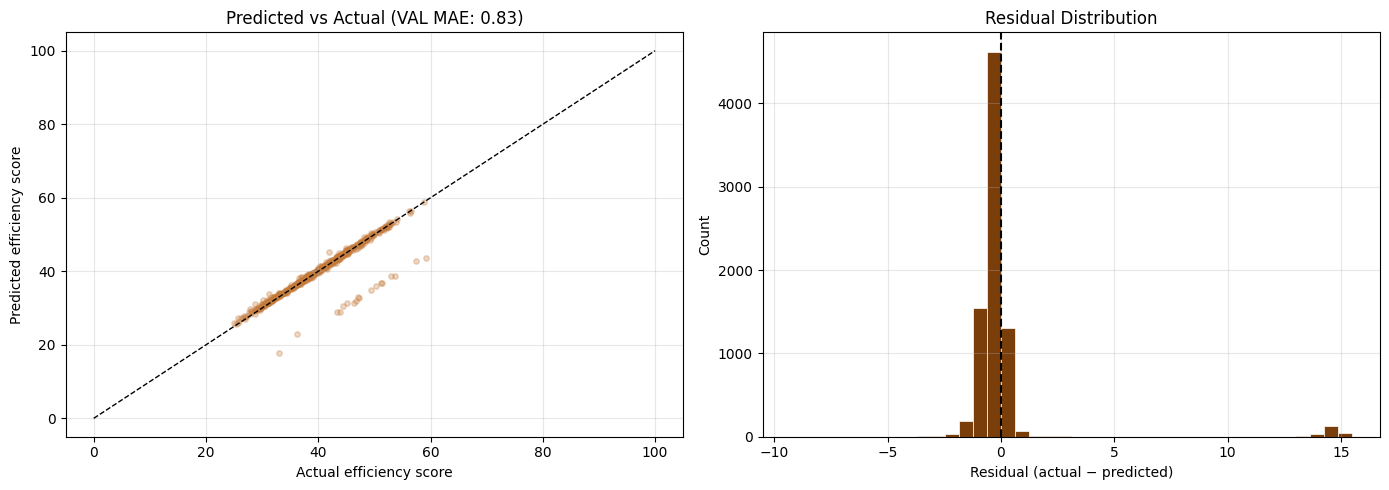

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predicted vs actual
axes[0].scatter(y_val[:500], val_pred[:500], alpha=0.3, color='#c47a3a', s=15)
axes[0].plot([0, 100], [0, 100], 'k--', lw=1)
axes[0].set_xlabel('Actual efficiency score')
axes[0].set_ylabel('Predicted efficiency score')
axes[0].set_title(f'Predicted vs Actual (VAL MAE: {val_mae:.2f})')
axes[0].grid(True, alpha=0.3)

# Residuals
residuals = y_val - val_pred
axes[1].hist(residuals, bins=40, color='#7a3e0a', edgecolor='white', linewidth=0.5)
axes[1].axvline(0, color='black', lw=1.5, linestyle='--')
axes[1].set_xlabel('Residual (actual − predicted)')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual Distribution')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Step 13 — Feature importance

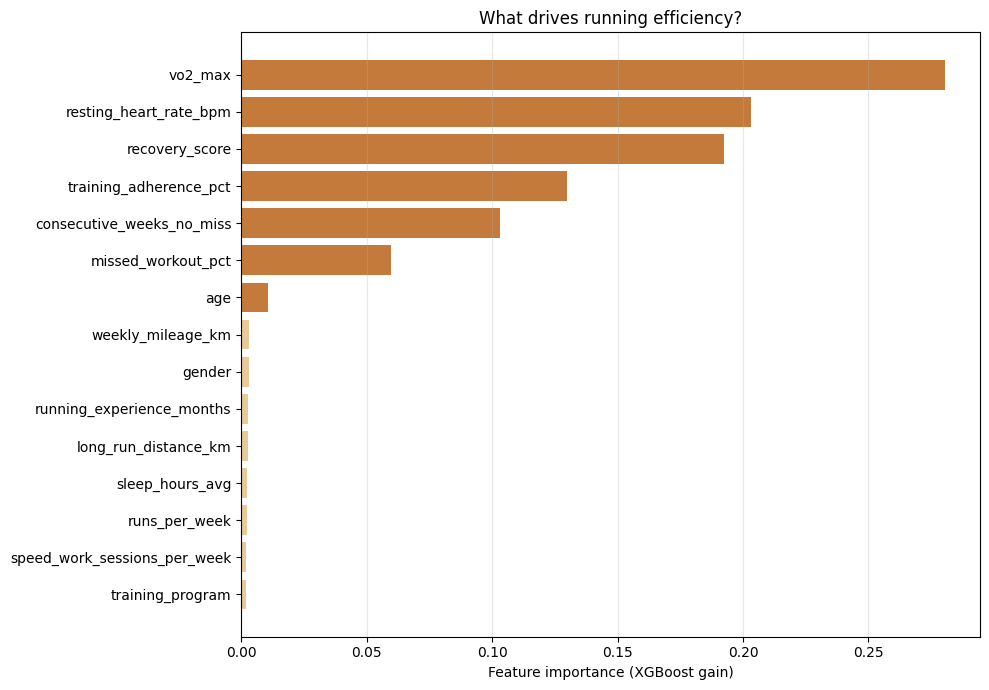


Top 5 most important features:
  vo2_max                                  0.280 ████████████████████████████
  resting_heart_rate_bpm                   0.203 ████████████████████
  recovery_score                           0.192 ███████████████████
  training_adherence_pct                   0.130 ████████████
  consecutive_weeks_no_miss                0.103 ██████████


In [13]:
importances = model.feature_importances_
feat_imp = pd.DataFrame({'feature': FEATURES, 'importance': importances})
feat_imp = feat_imp.sort_values('importance', ascending=True)

plt.figure(figsize=(10, 7))
colors = ['#c47a3a' if i > feat_imp['importance'].median() else '#e8c99a'
          for i in feat_imp['importance']]
plt.barh(feat_imp['feature'], feat_imp['importance'], color=colors)
plt.xlabel('Feature importance (XGBoost gain)')
plt.title('What drives running efficiency?')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print('\nTop 5 most important features:')
for _, row in feat_imp.sort_values('importance', ascending=False).head(5).iterrows():
    bar = '█' * int(row['importance'] * 100)
    print(f"  {row['feature']:<40} {row['importance']:.3f} {bar}")

## Step 14 — Efficiency score by training program

C:\Users\jtush\AppData\Local\Temp\ipykernel_19620\3990491203.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(data_by_prog, labels=programs, patch_artist=True)


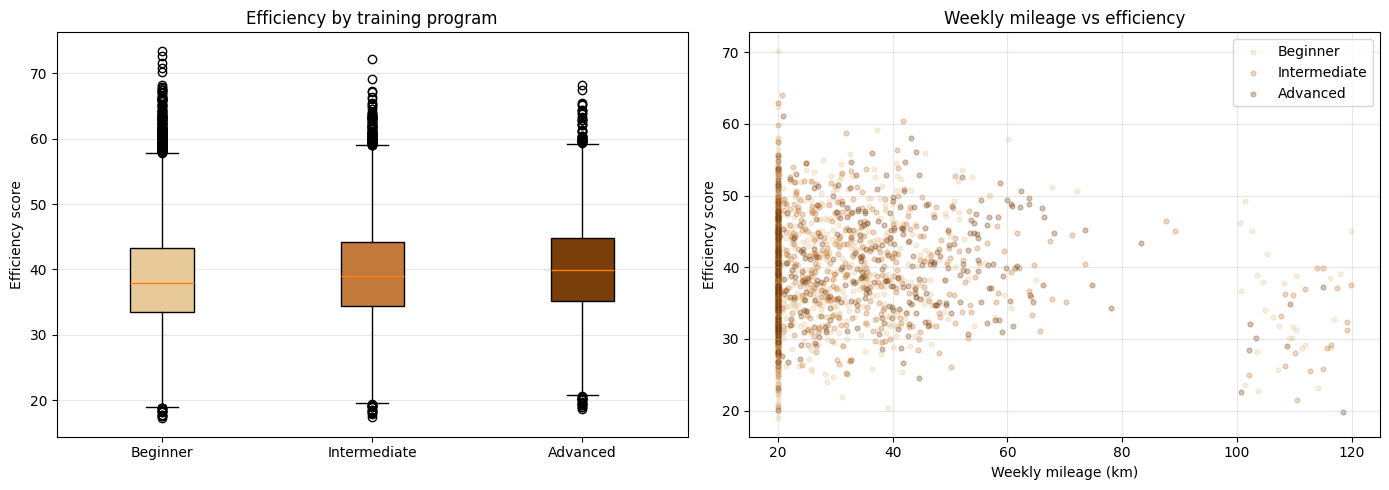

In [14]:
# Re-load original (before encoding) for readable labels
raw_train = pd.read_csv('train.csv')
raw_train['efficiency_score'] = train_df['efficiency_score'].values

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot by program
programs = ['Beginner', 'Intermediate', 'Advanced']
data_by_prog = [raw_train[raw_train['training_program'] == p]['efficiency_score'].dropna()
                for p in programs]
bp = axes[0].boxplot(data_by_prog, labels=programs, patch_artist=True)
colors_box = ['#e8c99a', '#c47a3a', '#7a3e0a']
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
axes[0].set_ylabel('Efficiency score')
axes[0].set_title('Efficiency by training program')
axes[0].grid(True, alpha=0.3, axis='y')

# Scatter: weekly mileage vs efficiency
sample = raw_train.sample(min(2000, len(raw_train)), random_state=42)
scatter_colors = {'Beginner': '#e8c99a', 'Intermediate': '#c47a3a', 'Advanced': '#7a3e0a'}
for prog in programs:
    sub = sample[sample['training_program'] == prog]
    axes[1].scatter(sub['weekly_mileage_km'], sub['efficiency_score'],
                   alpha=0.3, s=12, label=prog, color=scatter_colors[prog])
axes[1].set_xlabel('Weekly mileage (km)')
axes[1].set_ylabel('Efficiency score')
axes[1].set_title('Weekly mileage vs efficiency')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Step 15 — Save model

In [15]:
save_data = {
    'model':          model,
    'label_encoders': label_encoders,
    'features':       FEATURES,
    'fill_medians':   fill_medians,
}

with open('efficiency_model.pkl', 'wb') as f:
    pickle.dump(save_data, f)

print('efficiency_model.pkl saved successfully!')
print('Now restart predict_service.py — it will auto-load this model')

efficiency_model.pkl saved successfully!
Now restart predict_service.py — it will auto-load this model


## Step 16 — Quick prediction test
Edit the profile below to test with your own numbers.

In [ ]:
def encode(col, value):
    le = label_encoders[col]
    if value not in le.classes_:
        value = le.classes_[0]
    return int(le.transform([value])[0])

# Edit these values to match a runner profile
test_profile = {
    'weekly_mileage_km':              45,
    'runs_per_week':                   5,
    'long_run_distance_km':           18,
    'speed_work_sessions_per_week':    1,
    'training_adherence_pct':         80,
    'running_experience_months':      24,
    'resting_heart_rate_bpm':         58,
    'vo2_max':                        48,
    'recovery_score':                  7,
    'consecutive_weeks_no_miss':       8,
    'missed_workout_pct':             15,
    'sleep_hours_avg':                 7,
    'age':                            27,
    'gender':        encode('gender', 'Male'),
    'training_program': encode('training_program', 'Intermediate'),
}

feature_vector = [test_profile[f] for f in FEATURES]
predicted_score = model.predict(np.array(feature_vector).reshape(1, -1))[0]
predicted_score = round(min(100, max(0, predicted_score)), 1)

def get_label(score):
    if score >= 85: return 'Excellent form'
    if score >= 70: return 'Good form'
    if score >= 50: return 'Fair form'
    return 'Needs work'

def get_tip(score):
    if score >= 85: return 'Outstanding! Maintain your current training rhythm.'
    if score >= 70: return 'Try adding one tempo run per week to push above 85.'
    if score >= 50: return 'Focus on running at an even effort — avoid starting too fast.'
    return 'Start with short, easy runs to build a consistent pace base.'

print(f'Efficiency score: {predicted_score} / 100')
print(f'Label:            {get_label(predicted_score)}')
print(f'Tip:              {get_tip(predicted_score)}')

## Step 17 — Score zone breakdown

In [ ]:
# Show what % of runners fall in each zone
zones = {
    'Needs work  (0–49)':    ((train_df['efficiency_score'] < 50).sum()),
    'Fair        (50–69)':   ((train_df['efficiency_score'].between(50, 69)).sum()),
    'Good        (70–84)':   ((train_df['efficiency_score'].between(70, 84)).sum()),
    'Excellent   (85–100)':  ((train_df['efficiency_score'] >= 85).sum()),
}

total = sum(zones.values())
print('Score zone distribution:')
for zone, count in zones.items():
    pct = count / total * 100
    bar = '█' * int(pct / 2)
    print(f'  {zone}  {pct:5.1f}%  {bar}')

plt.figure(figsize=(8, 4))
zone_colors = ['#F09595', '#EF9F27', '#97C459', '#1D9E75']
plt.bar(zones.keys(), zones.values(), color=zone_colors, edgecolor='white')
plt.ylabel('Number of runners')
plt.title('Runners per efficiency zone')
plt.xticks(rotation=15, ha='right')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()